In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio

## 1. Frequency domain BF: Different directions

In [9]:
def shift_signal(signal, t):
    sampling_rate = signal.shape[0]
    shift = int(t*sampling_rate)
    shifted_sig = np.roll(signal, shift)
    if shift > 0:
        shifted_sig[:shift] = 0
    elif shift < 0:
        shifted_sig[shift:] = 0
    return shifted_sig
    
def wft(f1, f2, a1, a2, theta, title):
    t = 1
    fsample = 110000
    samples = np.linspace(0, t, fsample)
    freq1 = f1
    freq2 = f2
    sig3_1 = a1*np.sin(2*np.pi*freq1*samples)
    sig3_2 = a2*np.sin(2*np.pi*freq2*samples)
    tp = 3*int(fsample / max(freq1, freq2))
    
    sig3 = sig3_1 + sig3_2

    # Array response
    d = 0.3
    c0 = 340
    
    tpi = int((fsample/(t*max(freq1, freq2)))*5)
    tpf = int((fsample/(t*max(freq1, freq2)))*10)
    
    fig, ax = plt.subplots(figsize = (8, 4))
    p2 = 0.5*d*np.sin(theta*np.pi/180)/c0
    p1 = d*np.sin(theta*np.pi/180)/c0
    sig2a = shift_signal(sig3, p2)
    sig1a = shift_signal(sig3, p1)
    sig = sig1a + sig2a + sig3
    ax.plot(samples[tpi:tpf], sig3[tpi:tpf], label = '3', alpha = 0.5, ls = '--')
    ax.plot(samples[tpi:tpf], sig1a[tpi:tpf], label = '1', alpha = 0.5, ls = '--')
    ax.plot(samples[tpi:tpf], sig2a[tpi:tpf], label = '2', alpha = 0.5, ls = '--')
    ax.plot(samples[tpi:tpf], sig[tpi:tpf], label = 'Array', alpha = 0.7, color = 'purple')
    ax.legend()
    ax.set_ylabel("Amplitude")
    ax.set_xlabel("Time (s)")
    # ax.set_ylim([-1.5, 1.5])
    ax.axhline(0, color = 'grey', lw = 0.7)
    ax.set_title(f'Wavefront {title} angle: {theta}deg')
    plt.show(fig)
    plt.close(fig)

    return [sig1a, sig2a, sig3], samples, fig

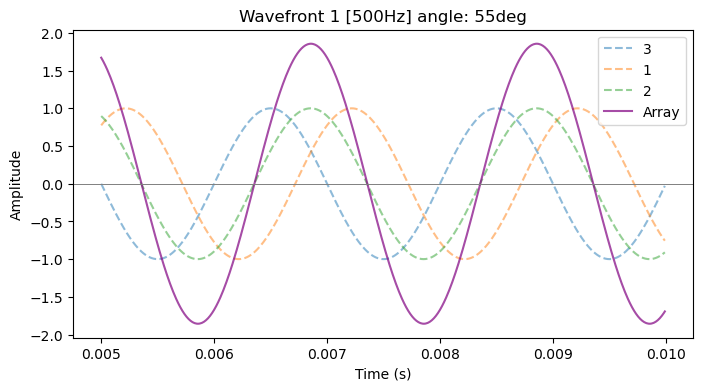

In [11]:
siga1, samples, fig1 = wft(500, 1000, 1, 0, 55, '1 [500Hz]')
# fig1.savefig('Signal1_DF.png')

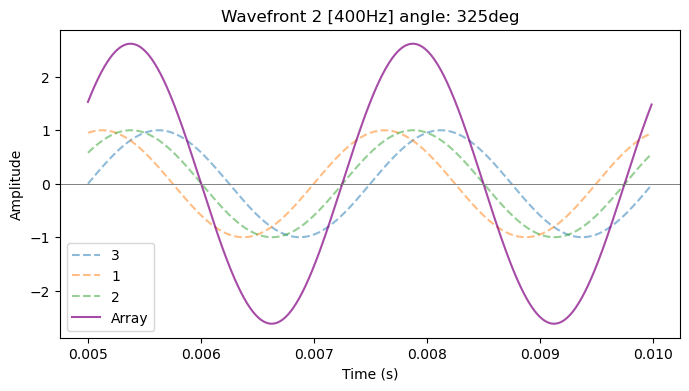

In [13]:
siga2, samples, fig2 = wft(400, 1000, 1, 0, 325, '2 [400Hz]')
# fig2.savefig('Signal2_DF.png')

Text(0.5, 0, 'Time (s)')

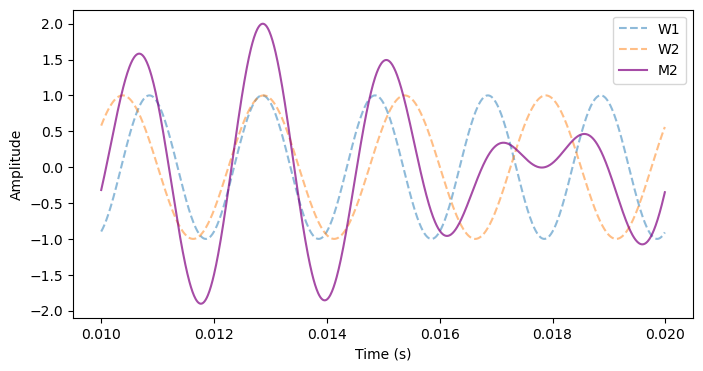

In [15]:
# Mic2
fsample = 110000
t = 1
fig, ax = plt.subplots(figsize = (8, 4))
freq1, freq2 = 400, 500
tpi = int((fsample/(t*max(freq1, freq2)))*5)
tpf = int((fsample/(t*max(freq1, freq2)))*10)
sig2a = siga1[1] + siga2[1]
ax.plot(samples[tpi:tpf], siga1[1][tpi:tpf], label = 'W1', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], siga2[1][tpi:tpf], label = 'W2', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], sig2a[tpi:tpf], label = 'M2', alpha = 0.7, color = 'purple')
ax.legend()
ax.set_ylabel("Amplitude")
ax.set_xlabel("Time (s)")
# fig.savefig('DF_M2.png')

Text(0.5, 0, 'Time (s)')

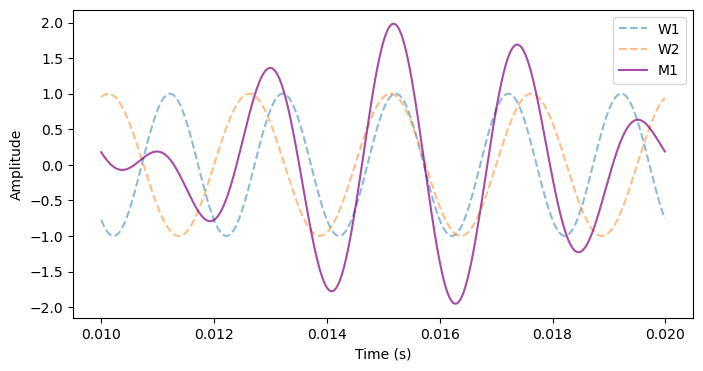

In [17]:
# Mic1
fig, ax = plt.subplots(figsize = (8, 4))
freq1, freq2 = 400, 500
tpi = int((fsample/(t*max(freq1, freq2)))*5)
tpf = int((fsample/(t*max(freq1, freq2)))*10)
sig1a = siga1[0] + siga2[0]
ax.plot(samples[tpi:tpf], siga1[0][tpi:tpf], label = 'W1', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], siga2[0][tpi:tpf], label = 'W2', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], sig1a[tpi:tpf], label = 'M1', alpha = 0.7, color = 'purple')
ax.legend()
ax.set_ylabel("Amplitude")
ax.set_xlabel("Time (s)")
# fig.savefig('DF_M1.png')

Text(0.5, 0, 'Time (s)')

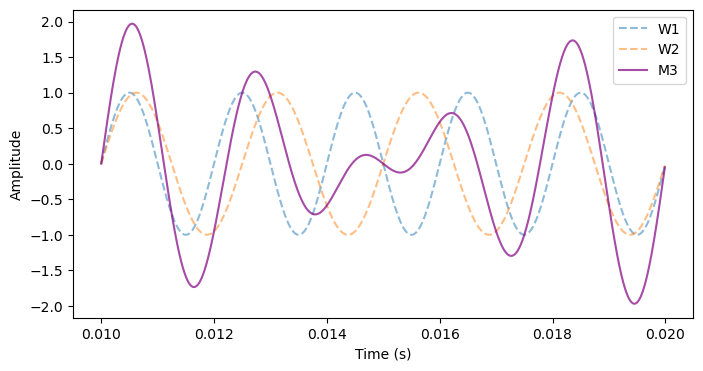

In [19]:
#Mic 3
fig, ax = plt.subplots(figsize = (8, 4))
freq1, freq2 = 400, 500
tpi = int((fsample/(t*max(freq1, freq2)))*5)
tpf = int((fsample/(t*max(freq1, freq2)))*10)
sig3a = siga1[2] + siga2[2]
ax.plot(samples[tpi:tpf], siga1[2][tpi:tpf], label = 'W1', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], siga2[2][tpi:tpf], label = 'W2', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], sig3a[tpi:tpf], label = 'M3', alpha = 0.7, color = 'purple')
ax.legend()
ax.set_ylabel("Amplitude")
ax.set_xlabel("Time (s)")
# fig.savefig('DF_M3.png')

Text(0.5, 1.0, 'Total array response')

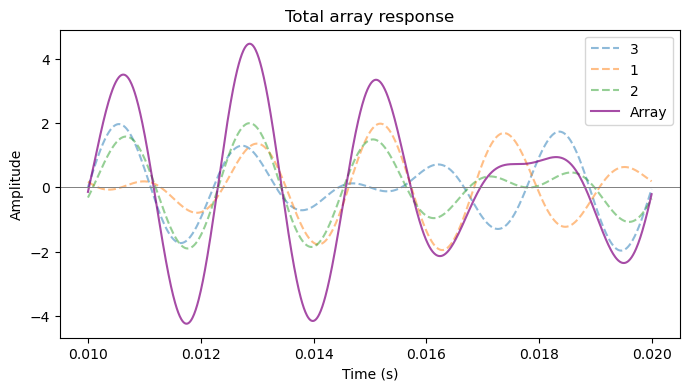

In [21]:
# Total array response
sig3 = siga1[2] + siga2[2]
sig2a = siga1[1] + siga2[1]
sig1a = siga1[0] + siga2[0]
sig = sig1a + sig2a + sig3

freq1, freq2 = 400, 500
tpi = int((fsample/(t*max(freq1, freq2)))*5)
tpf = int((fsample/(t*max(freq1, freq2)))*10)

fig, ax = plt.subplots(figsize = (8, 4))

ax.plot(samples[tpi:tpf], sig3[tpi:tpf], label = '3', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], sig1a[tpi:tpf], label = '1', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], sig2a[tpi:tpf], label = '2', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], sig[tpi:tpf], label = 'Array', alpha = 0.7, color = 'purple')
ax.legend()
ax.set_ylabel("Amplitude")
ax.set_xlabel("Time (s)")
# ax.set_ylim([-1.5, 1.5])
ax.axhline(0, color = 'grey', lw = 0.7)
ax.set_title(f'Total array response')
# fig.savefig('DF_recordings.png')

## 2. Fourier Transform each mic recording, separate out the phase and amplitude info

In [23]:
for i, sig in enumerate([sig1a, sig2a, sig3]):
    df = pd.DataFrame(sig, samples).rename(columns = {0:'Signal'})
    df.index.name = 'time'
    df.to_csv(f'Signal_{i + 1}.csv')

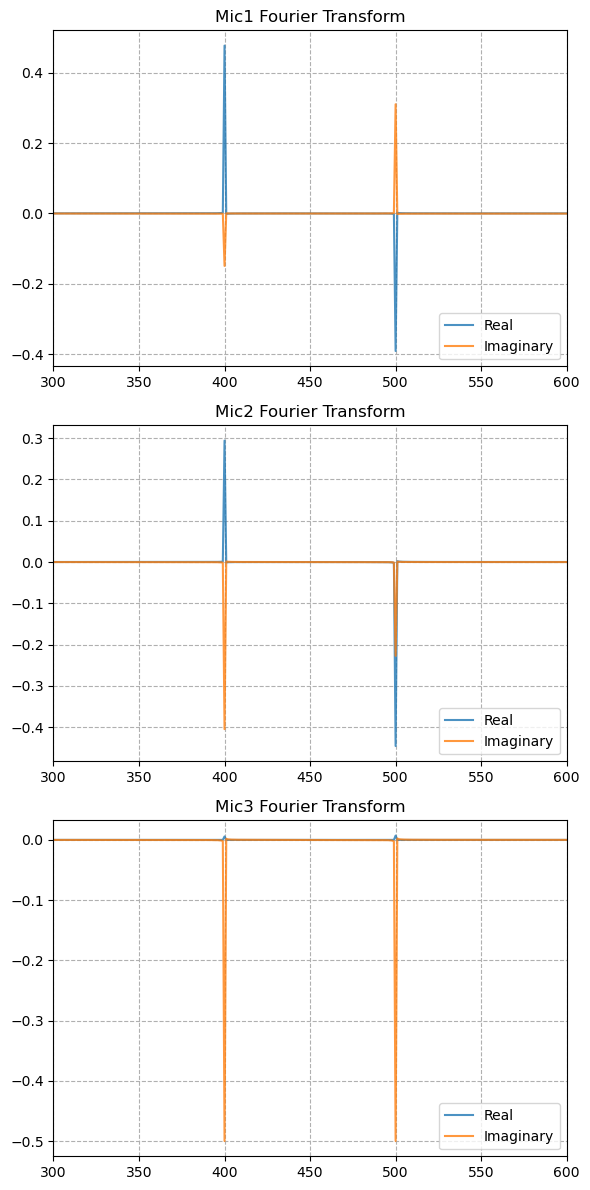

In [24]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(6, 12))
for i, ax in enumerate(axs):
    filename = f'FFT_{i+1}.csv'
    dff = pd.read_csv(filename)
    dff = dff.rename(columns = {'Img: unnamed':'Img', 'Real: unnamed':'Re'})
    ax.plot(dff['Frequency (/s)'], dff['Re'], label = 'Real', alpha = 0.8)
    ax.plot(dff['Frequency (/s)'], dff['Img'], label = 'Imaginary', alpha = 0.8)
    ax.legend(loc='lower right')
    ax.set_xlim([300, 600])
    ax.set_title(f'Mic{i+1} Fourier Transform')
    ax.grid(visible=True, which='major', axis='both', ls = '--')
plt.tight_layout()
plt.show()

In [27]:
f400, f500 = [], []
for i in [1, 2, 3]:
    filename = f'FFT_{i}.csv'
    dff = pd.read_csv(filename)
    dff = dff.rename(columns = {'Img: unnamed':'Img', 'Real: unnamed':'Re'})
    ffv = []
    for ff in [400, 500]:
        re = dff[round(dff['Frequency (/s)'], 2) == ff]['Re'].values[0]
        img = dff[round(dff['Frequency (/s)'], 2) == ff]['Img'].values[0]
        ffv.append(re + 1j*img)
    f400.append(ffv[0])
    f500.append(ffv[1])

In [29]:
FT = dict()
FT[400] = f400
FT[500] = f500

## 3. Steering: Frequency domain, and Beamform

In [32]:
def steering_vect(d, theta, f):
    c0 = 340
    td2 = 0.5*d*np.sin(theta*np.pi/180)/c0
    td1 = d*np.sin(theta*np.pi/180)/c0
    sv2 = np.exp(-2*np.pi*f*1j*td2)
    sv1 = np.exp(-2*np.pi*f*1j*td1)
    return np.array([sv1, sv2, 1])

In [40]:
tmax = 360
BF = dict()
thetas = np.linspace(0, tmax, tmax + 1)
for f in [400, 500]:
    bf_freq = []
    for theta0 in thetas:
        a = steering_vect(d = 0.3, theta = theta0, f = f)
        bf_val = np.abs(np.vdot(a, FT[f]))**2
        bf_freq.append(bf_val)
    BF[f] = bf_freq

In [158]:
rad = np.array(BF[400])
x = rad * np.cos(np.roll(thetas, 90)*np.pi/180)
y = rad * np.sin(np.roll(thetas, 90)*np.pi/180)

frames = []

for i, thet in enumerate(np.roll(thetas, 90)):
    fig, ax = plt.subplots(figsize=(6,6))
    ax.plot(x, y)
    ax.axis('equal') # Crucial to ensure it doesn't look distorted
    ax.grid(True, ls = '--')
    ax.scatter(0, 0, color = 'black')
    # ax.plot([0, x[225]], [0, y[225]], color = 'red')
    ax.quiver(0, 0, np.roll(x[::-1], 0)[i], np.roll(y[::-1], 0)[i], angles='xy', scale_units='xy', scale=1, color='red', lw = 0.1,  width=0.006)
    ax.set_title(f'Angle: {thetas[i-180]}°')
    fig.canvas.draw()
    rgba_buffer = fig.canvas.buffer_rgba()
    image = np.array(rgba_buffer)
    image_rgb = image[:, :, :3]
    frames.append(image_rgb)
    plt.close(fig)
imageio.mimsave('steering_BF.gif', frames, fps = 20, loop=0)

In [160]:
rad = np.array(BF[500])
x = rad * np.cos(np.roll(thetas, 90)*np.pi/180)
y = rad * np.sin(np.roll(thetas, 90)*np.pi/180)

frames = []

for i, thet in enumerate(np.roll(thetas, 90)):
    fig, ax = plt.subplots(figsize=(6,6))
    ax.plot(x, y)
    ax.axis('equal') # Crucial to ensure it doesn't look distorted
    ax.grid(True, ls = '--')
    ax.scatter(0, 0, color = 'black')
    # ax.plot([0, x[225]], [0, y[225]], color = 'red')
    ax.quiver(0, 0, np.roll(x[::-1], 0)[i], np.roll(y[::-1], 0)[i], angles='xy', scale_units='xy', scale=1, color='red', lw = 0.1,  width=0.006)
    ax.set_title(f'Angle: {thetas[i-180]}°')
    fig.canvas.draw()
    rgba_buffer = fig.canvas.buffer_rgba()
    image = np.array(rgba_buffer)
    image_rgb = image[:, :, :3]
    frames.append(image_rgb)
    plt.close(fig)
imageio.mimsave('steering_BF_500.gif', frames, fps = 20, loop=0)

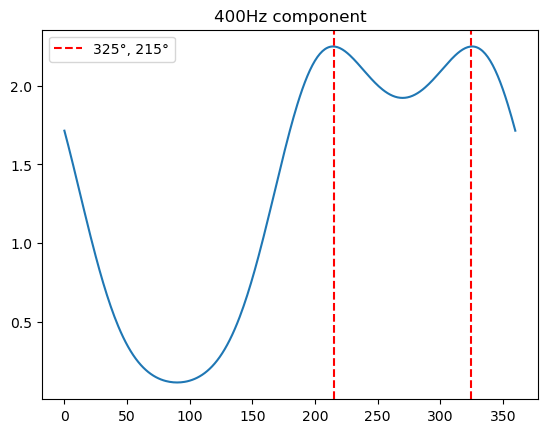

In [166]:
plt.plot(BF[400])
plt.title('400Hz component')
ang = 325
plt.axvline(ang, color = 'r', ls = '--', label = f'{ang}°, {360 - ang + 180}°')
plt.axvline(360 - ang + 180, color = 'r', ls = '--')
plt.legend()
plt.show()

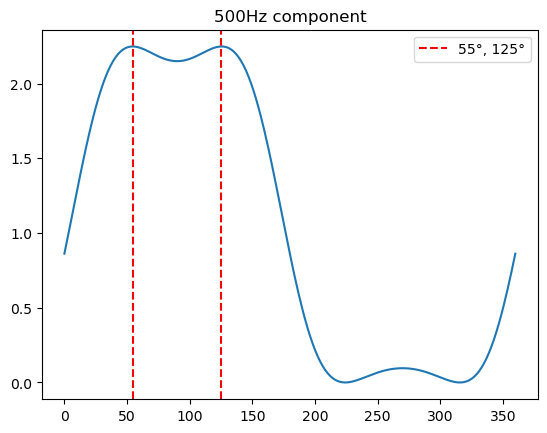

In [172]:
plt.plot(BF[500])
plt.title('500Hz component')
ang = 55
plt.axvline(ang, color = 'r', ls = '--', label = f'{ang}°, {-ang + 180}°')
plt.axvline(180 - ang, color = 'r', ls = '--')
plt.legend()
plt.show()

## 4. Example 2

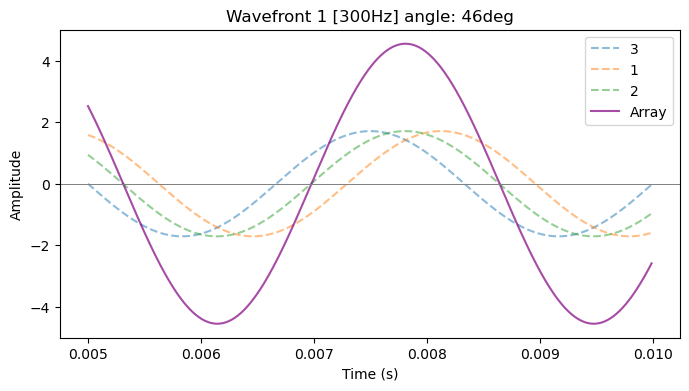

In [226]:
siga1, samples, fig1 = wft(300, 1000, 1.71, 0, 46, '1 [300Hz]')

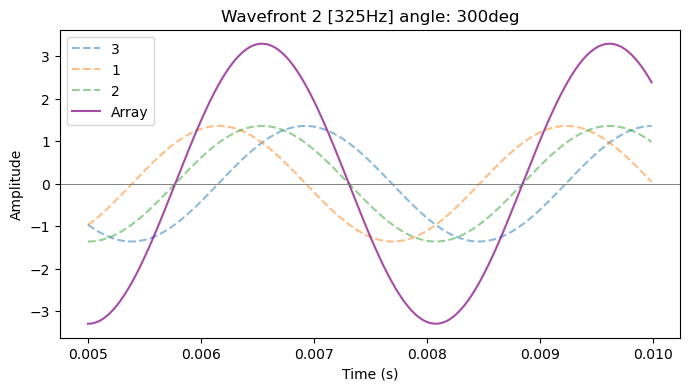

In [228]:
siga2, samples, fig2 = wft(325, 1000, 1.36, 0, 300, '2 [325Hz]')

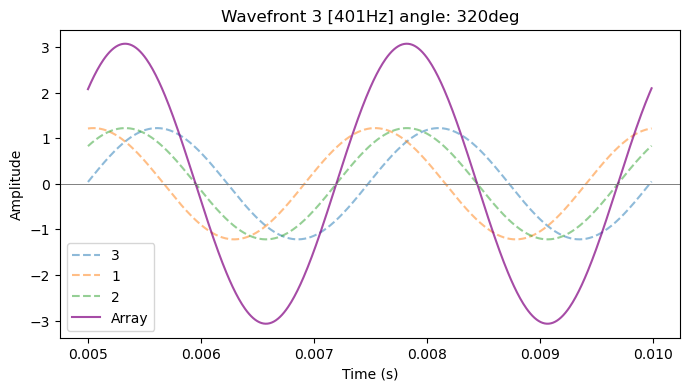

In [238]:
siga3, samples, fig3 = wft(401, 1000, 1.22, 0, 320, '3 [401Hz]')

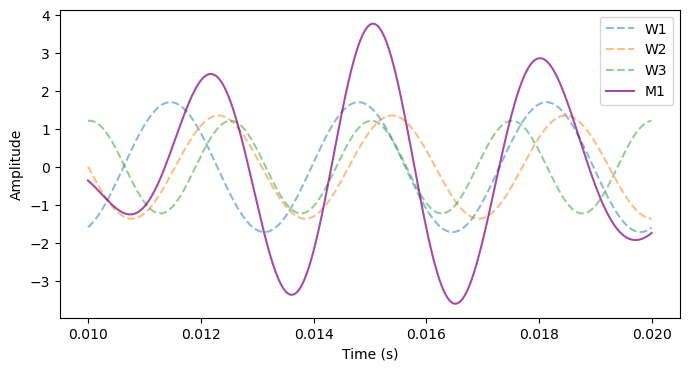

In [240]:
# Mic1
fig, ax = plt.subplots(figsize = (8, 4))
freq1, freq2 = 400, 500
tpi = int((fsample/(t*max(freq1, freq2)))*5)
tpf = int((fsample/(t*max(freq1, freq2)))*10)
sig1a = siga1[0] + siga2[0] + siga3[0]
ax.plot(samples[tpi:tpf], siga1[0][tpi:tpf], label = 'W1', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], siga2[0][tpi:tpf], label = 'W2', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], siga3[0][tpi:tpf], label = 'W3', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], sig1a[tpi:tpf], label = 'M1', alpha = 0.7, color = 'purple')
ax.legend()
ax.set_ylabel("Amplitude")
ax.set_xlabel("Time (s)")
fig.savefig('DF_E2_M1.png')

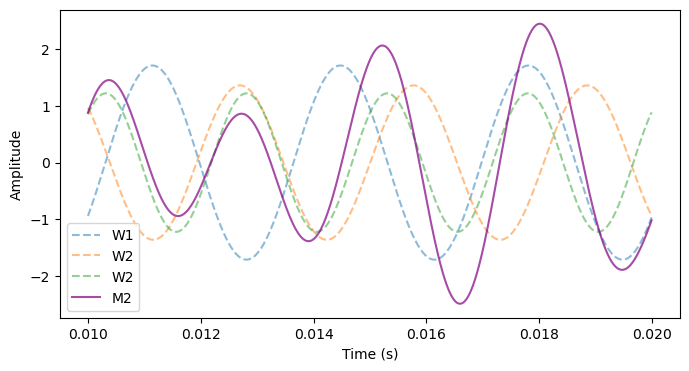

In [242]:
# Mic2
fsample = 110000
t = 1
fig, ax = plt.subplots(figsize = (8, 4))
freq1, freq2 = 400, 500
tpi = int((fsample/(t*max(freq1, freq2)))*5)
tpf = int((fsample/(t*max(freq1, freq2)))*10)
sig2a = siga1[1] + siga2[1] + siga3[1]
ax.plot(samples[tpi:tpf], siga1[1][tpi:tpf], label = 'W1', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], siga2[1][tpi:tpf], label = 'W2', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], siga3[1][tpi:tpf], label = 'W2', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], sig2a[tpi:tpf], label = 'M2', alpha = 0.7, color = 'purple')
ax.legend()
ax.set_ylabel("Amplitude")
ax.set_xlabel("Time (s)")
fig.savefig('DF_E2_M2.png')

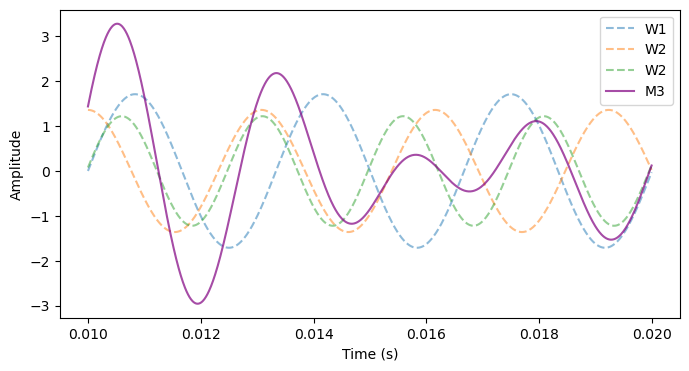

In [244]:
#Mic 3
fig, ax = plt.subplots(figsize = (8, 4))
freq1, freq2 = 400, 500
tpi = int((fsample/(t*max(freq1, freq2)))*5)
tpf = int((fsample/(t*max(freq1, freq2)))*10)
sig3a = siga1[2] + siga2[2] + siga3[2]
ax.plot(samples[tpi:tpf], siga1[2][tpi:tpf], label = 'W1', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], siga2[2][tpi:tpf], label = 'W2', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], siga3[2][tpi:tpf], label = 'W2', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], sig3a[tpi:tpf], label = 'M3', alpha = 0.7, color = 'purple')
ax.legend()
ax.set_ylabel("Amplitude")
ax.set_xlabel("Time (s)")
fig.savefig('DF_E2_M3.png')

In [246]:
for i, sig in enumerate([sig1a, sig2a, sig3a]):
    df = pd.DataFrame(sig, samples).rename(columns = {0:'Signal'})
    df.index.name = 'time'
    df.to_csv(f'Signal_{i + 1}_E2.csv')

In [284]:
f1, f2, f3 = [], [], []
for i in [1, 2, 3]:
    filename = f'FFT_{i}_E2.csv'
    dff = pd.read_csv(filename)
    dff = dff.rename(columns = {'Img: unnamed':'Img', 'Real: unnamed':'Re'})
    ffv = []
    for ff in [300, 325, 401]:
        re = dff[round(dff['Frequency (/s)'], 2) == ff]['Re'].values[0]
        img = dff[round(dff['Frequency (/s)'], 2) == ff]['Img'].values[0]
        ffv.append(re + 1j*img)
    f1.append(ffv[0])
    f2.append(ffv[1])
    f3.append(ffv[2])

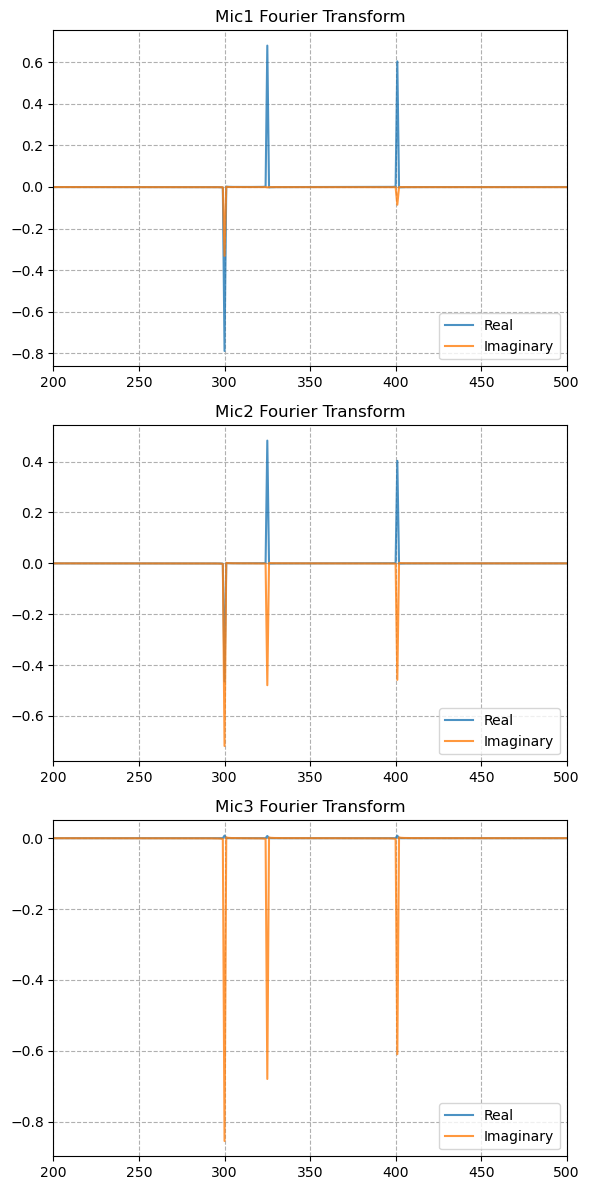

In [286]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(6, 12))
for i, ax in enumerate(axs):
    filename = f'FFT_{i+1}_E2.csv'
    dff = pd.read_csv(filename)
    dff = dff.rename(columns = {'Img: unnamed':'Img', 'Real: unnamed':'Re'})
    ax.plot(dff['Frequency (/s)'], dff['Re'], label = 'Real', alpha = 0.8)
    ax.plot(dff['Frequency (/s)'], dff['Img'], label = 'Imaginary', alpha = 0.8)
    ax.legend(loc='lower right')
    ax.set_xlim([200, 500])
    ax.set_title(f'Mic{i+1} Fourier Transform')
    ax.grid(visible=True, which='major', axis='both', ls = '--')
plt.tight_layout()
plt.show()

In [288]:
FT = dict()
FT[300] = f1
FT[325] = f2
FT[401] = f3

In [290]:
tmax = 360
BF = dict()
thetas = np.linspace(0, tmax, tmax + 1)
for f in [300, 325, 401]:
    bf_freq = []
    for theta0 in thetas:
        a = steering_vect(d = 0.3, theta = theta0, f = f)
        bf_val = np.abs(np.vdot(a, FT[f]))**2
        bf_freq.append(bf_val)
    BF[f] = bf_freq

In [326]:
rad = np.array(BF[300])
x = rad * np.cos(np.roll(thetas, 90)*np.pi/180)
y = rad * np.sin(np.roll(thetas, 90)*np.pi/180)

frames = []

for i, thet in enumerate(np.roll(thetas, 90)):
    fig, ax = plt.subplots(figsize=(6,6))
    ax.plot(x, y)
    ax.axis('equal') # Crucial to ensure it doesn't look distorted
    ax.grid(True, ls = '--')
    ax.scatter(0, 0, color = 'black')
    # ax.plot([0, x[225]], [0, y[225]], color = 'red')
    ax.quiver(0, 0, np.roll(x[::-1], 0)[i], np.roll(y[::-1], 0)[i], angles='xy', scale_units='xy', scale=1, color='red', lw = 0.1,  width=0.006)
    ax.set_title(f'440Hz | Angle: {thetas[i-180]}°')
    fig.canvas.draw()
    rgba_buffer = fig.canvas.buffer_rgba()
    image = np.array(rgba_buffer)
    image_rgb = image[:, :, :3]
    frames.append(image_rgb)
    plt.close(fig)
imageio.mimsave('steering_BF_300.gif', frames, fps = 20, loop=0)

In [327]:
rad = np.array(BF[325])
x = rad * np.cos(np.roll(thetas, 90)*np.pi/180)
y = rad * np.sin(np.roll(thetas, 90)*np.pi/180)

frames = []

for i, thet in enumerate(np.roll(thetas, 90)):
    fig, ax = plt.subplots(figsize=(6,6))
    ax.plot(x, y)
    ax.axis('equal') # Crucial to ensure it doesn't look distorted
    ax.grid(True, ls = '--')
    ax.scatter(0, 0, color = 'black')
    # ax.plot([0, x[225]], [0, y[225]], color = 'red')
    ax.quiver(0, 0, np.roll(x[::-1], 0)[i], np.roll(y[::-1], 0)[i], angles='xy', scale_units='xy', scale=1, color='red', lw = 0.1,  width=0.006)
    ax.set_title(f'375Hz | Angle: {thetas[i-180]}°')
    fig.canvas.draw()
    rgba_buffer = fig.canvas.buffer_rgba()
    image = np.array(rgba_buffer)
    image_rgb = image[:, :, :3]
    frames.append(image_rgb)
    plt.close(fig)
imageio.mimsave('steering_BF_325.gif', frames, fps = 20, loop=0)

In [328]:
rad = np.array(BF[401])
x = rad * np.cos(np.roll(thetas, 90)*np.pi/180)
y = rad * np.sin(np.roll(thetas, 90)*np.pi/180)

frames = []

for i, thet in enumerate(np.roll(thetas, 90)):
    fig, ax = plt.subplots(figsize=(6,6))
    ax.plot(x, y)
    ax.axis('equal') # Crucial to ensure it doesn't look distorted
    ax.grid(True, ls = '--')
    ax.scatter(0, 0, color = 'black')
    # ax.plot([0, x[225]], [0, y[225]], color = 'red')
    ax.quiver(0, 0, np.roll(x[::-1], 0)[i], np.roll(y[::-1], 0)[i], angles='xy', scale_units='xy', scale=1, color='red', lw = 0.1,  width=0.006)
    ax.set_title(f'375Hz | Angle: {thetas[i-180]}°')
    fig.canvas.draw()
    rgba_buffer = fig.canvas.buffer_rgba()
    image = np.array(rgba_buffer)
    image_rgb = image[:, :, :3]
    frames.append(image_rgb)
    plt.close(fig)
imageio.mimsave('steering_BF_401.gif', frames, fps = 20, loop=0)

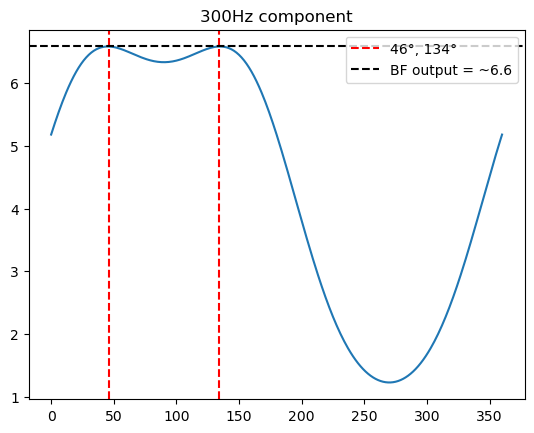

In [316]:
plt.plot(BF[300])
plt.title('300Hz component')
ang = 46
plt.axvline(ang, color = 'r', ls = '--', label = f'{ang}°, {-ang + 180}°')
plt.axvline(180 - ang, color = 'r', ls = '--')
plt.axhline(max(BF[300]), color = 'black', ls = '--', label = f'BF output = ~{round(max(BF[300]), 1)}')
plt.legend()

plt.savefig(f'{ang}.png')
plt.show()

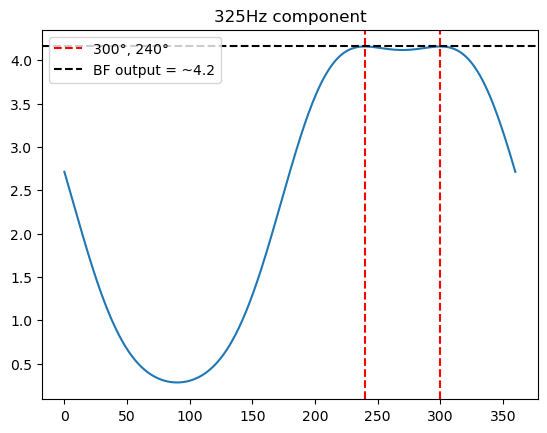

In [322]:
plt.plot(BF[325])
plt.title('325Hz component')
ang = 300
plt.axvline(ang, color = 'r', ls = '--', label = f'{ang}°, {360 - ang + 180}°')
plt.axvline(360 - ang + 180, color = 'r', ls = '--')
plt.axhline(max(BF[325]), color = 'black', ls = '--', label = f'BF output = ~{round(max(BF[325]), 1)}')
plt.legend()
plt.savefig(f'{ang}.png')
plt.show()

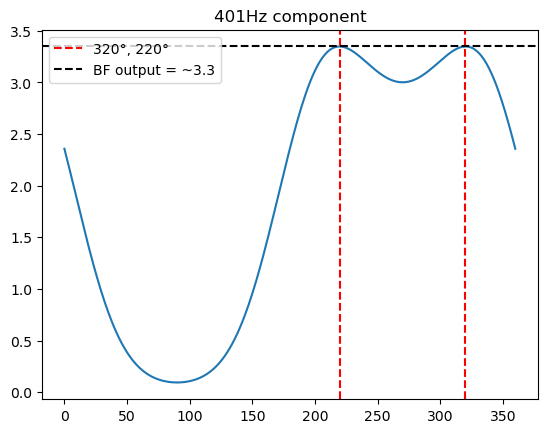

In [324]:
plt.plot(BF[401])
plt.title('401Hz component')
ang = 320
plt.axvline(ang, color = 'r', ls = '--', label = f'{ang}°, {360 - ang + 180}°')
plt.axvline(360 - ang + 180, color = 'r', ls = '--')
plt.axhline(max(BF[401]), color = 'black', ls = '--', label = f'BF output = ~{round(max(BF[401]), 1)}')
plt.legend()
plt.savefig(f'{ang}.png')
plt.show()

In [348]:
max(BF[300])

6.583147280296502

In [350]:
max(BF[325])

4.159952951829017

In [352]:
max(BF[401])

3.3475425556171596

## Example 3: Two signals from different directions, but same frequency

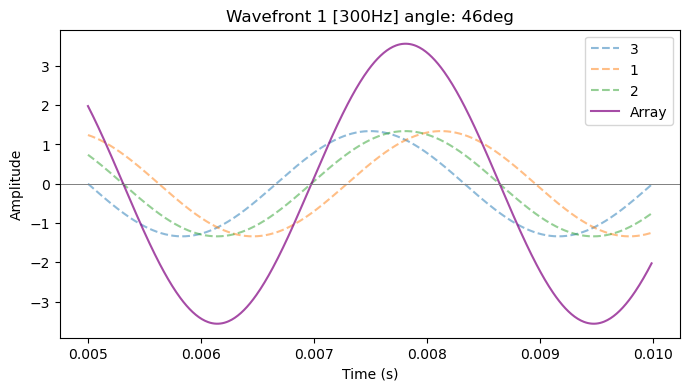

In [369]:
siga1, samples, fig1 = wft(300, 1000, 1.34, 0, 46, '1 [300Hz]')

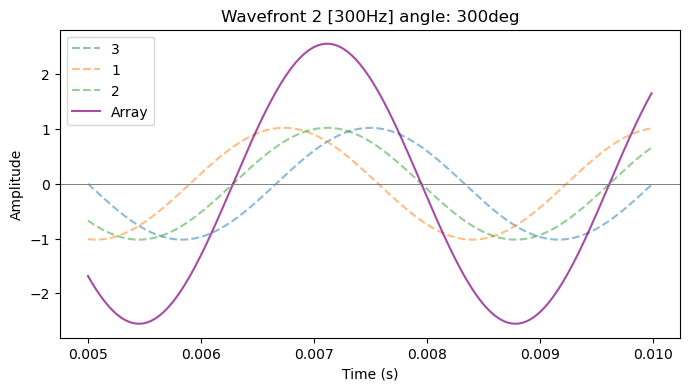

In [371]:
siga2, samples, fig1 = wft(300, 1000, 1.02, 0, 300, '2 [300Hz]')

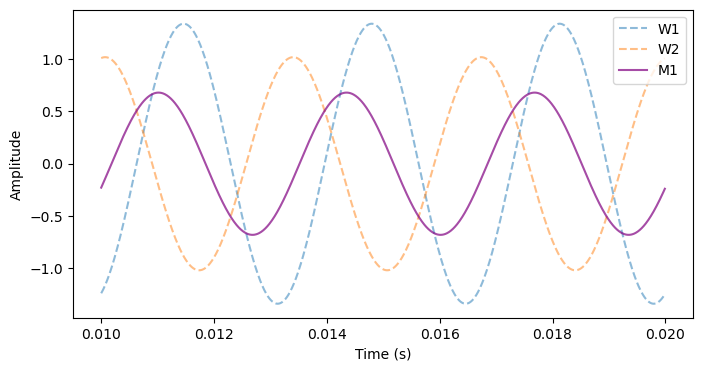

In [373]:
# Mic1
fig, ax = plt.subplots(figsize = (8, 4))
freq1, freq2 = 400, 500
tpi = int((fsample/(t*max(freq1, freq2)))*5)
tpf = int((fsample/(t*max(freq1, freq2)))*10)
sig1a = siga1[0] + siga2[0]
ax.plot(samples[tpi:tpf], siga1[0][tpi:tpf], label = 'W1', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], siga2[0][tpi:tpf], label = 'W2', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], sig1a[tpi:tpf], label = 'M1', alpha = 0.7, color = 'purple')
ax.legend()
ax.set_ylabel("Amplitude")
ax.set_xlabel("Time (s)")
fig.savefig('DF_E3_M1.png')

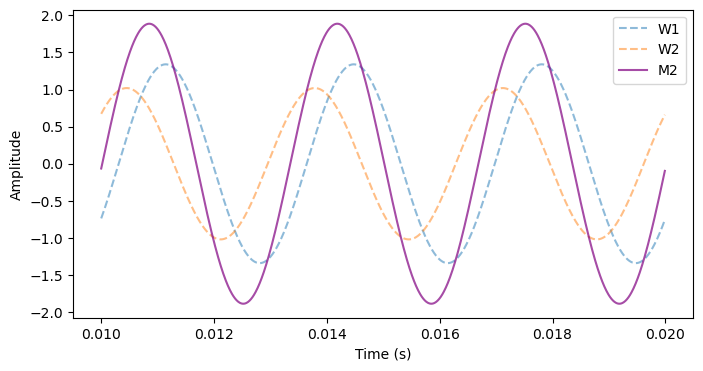

In [375]:
# Mic2
fsample = 110000
t = 1
fig, ax = plt.subplots(figsize = (8, 4))
freq1, freq2 = 400, 500
tpi = int((fsample/(t*max(freq1, freq2)))*5)
tpf = int((fsample/(t*max(freq1, freq2)))*10)
sig2a = siga1[1] + siga2[1]
ax.plot(samples[tpi:tpf], siga1[1][tpi:tpf], label = 'W1', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], siga2[1][tpi:tpf], label = 'W2', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], sig2a[tpi:tpf], label = 'M2', alpha = 0.7, color = 'purple')
ax.legend()
ax.set_ylabel("Amplitude")
ax.set_xlabel("Time (s)")
fig.savefig('DF_E3_M2.png')

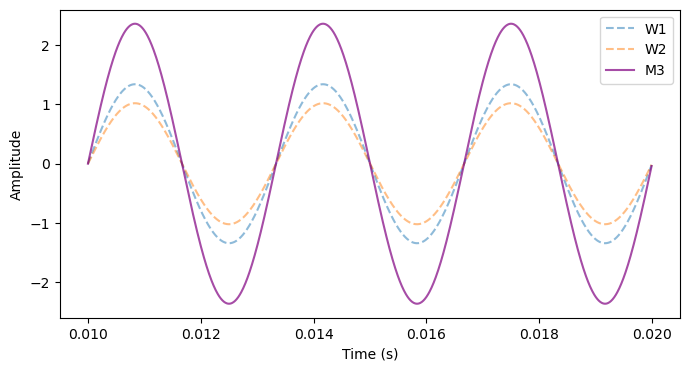

In [377]:
#Mic 3
fig, ax = plt.subplots(figsize = (8, 4))
freq1, freq2 = 400, 500
tpi = int((fsample/(t*max(freq1, freq2)))*5)
tpf = int((fsample/(t*max(freq1, freq2)))*10)
sig3a = siga1[2] + siga2[2]
ax.plot(samples[tpi:tpf], siga1[2][tpi:tpf], label = 'W1', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], siga2[2][tpi:tpf], label = 'W2', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], sig3a[tpi:tpf], label = 'M3', alpha = 0.7, color = 'purple')
ax.legend()
ax.set_ylabel("Amplitude")
ax.set_xlabel("Time (s)")
fig.savefig('DF_E3_M3.png')

In [379]:
for i, sig in enumerate([sig1a, sig2a, sig3a]):
    df = pd.DataFrame(sig, samples).rename(columns = {0:'Signal'})
    df.index.name = 'time'
    df.to_csv(f'Signal_{i + 1}_E3.csv')

In [381]:
f1 = []
for i in [1, 2, 3]:
    filename = f'FFT_{i}_E3.csv'
    dff = pd.read_csv(filename)
    dff = dff.rename(columns = {'Img: unnamed':'Img', 'Real: unnamed':'Re'})
    ffv = []
    for ff in [300]:
        re = dff[round(dff['Frequency (/s)'], 2) == ff]['Re'].values[0]
        img = dff[round(dff['Frequency (/s)'], 2) == ff]['Img'].values[0]
        ffv.append(re + 1j*img)
    f1.append(ffv[0])

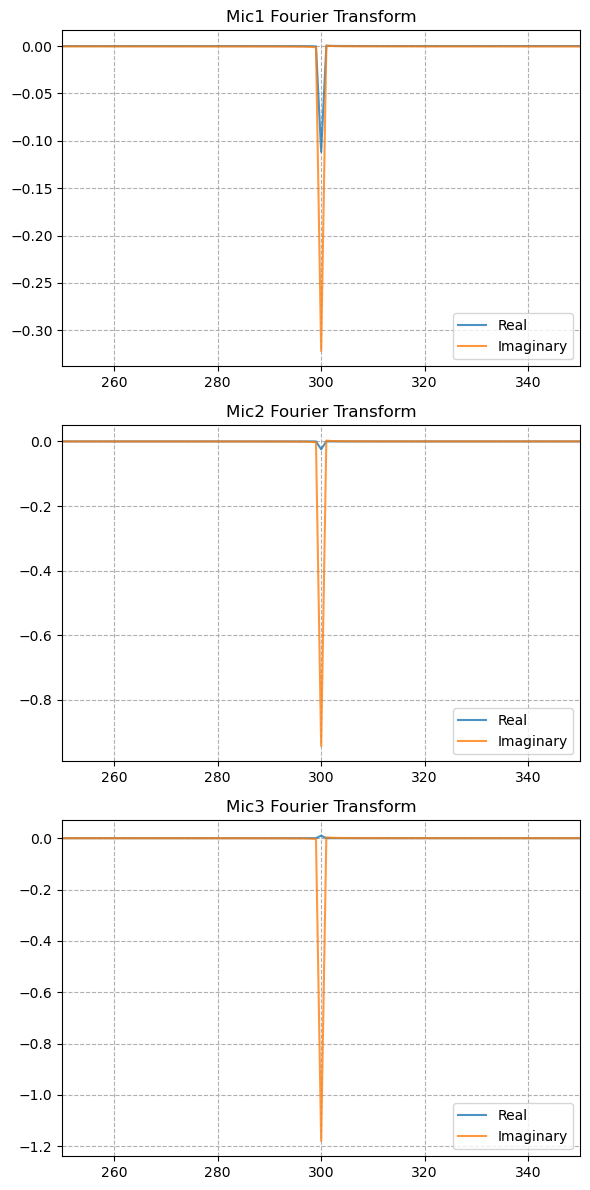

In [383]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(6, 12))
for i, ax in enumerate(axs):
    filename = f'FFT_{i+1}_E3.csv'
    dff = pd.read_csv(filename)
    dff = dff.rename(columns = {'Img: unnamed':'Img', 'Real: unnamed':'Re'})
    ax.plot(dff['Frequency (/s)'], dff['Re'], label = 'Real', alpha = 0.8)
    ax.plot(dff['Frequency (/s)'], dff['Img'], label = 'Imaginary', alpha = 0.8)
    ax.legend(loc='lower right')
    ax.set_xlim([250, 350])
    ax.set_title(f'Mic{i+1} Fourier Transform')
    ax.grid(visible=True, which='major', axis='both', ls = '--')
plt.tight_layout()
plt.show()

In [385]:
FT = dict()
FT[300] = f1

In [387]:
tmax = 360
BF = dict()
thetas = np.linspace(0, tmax, tmax + 1)
for f in [300]:
    bf_freq = []
    for theta0 in thetas:
        a = steering_vect(d = 0.3, theta = theta0, f = f)
        bf_val = np.abs(np.vdot(a, FT[f]))**2
        bf_freq.append(bf_val)
    BF[f] = bf_freq

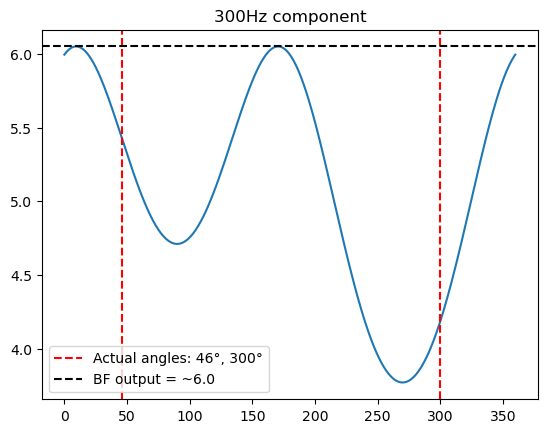

In [391]:
plt.plot(BF[300])
plt.title('300Hz component')
ang = 46
plt.axvline(ang, color = 'red', ls = '--', label = f'Actual angles: {ang}°, 300°')
plt.axvline(300, color = 'red', ls = '--')
plt.axhline(max(BF[300]), color = 'black', ls = '--', label = f'BF output = ~{round(max(BF[300]), 1)}')
plt.legend()

# plt.savefig(f'{ang}.png')
plt.show()